# 4-Lobe Lightbridge Fuel

## Gas Displacer

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import kaist
from ttnte.cad.curves import qtrlobe
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig
from ttnte.cad import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = kaist()

In [3]:
D = 1.26 # Fuel width
D2 = D*0.5
X = 1.36 # Channel pitch
delta = 0.306 # Width of lobes
y2 = delta * 0.5
d = 0.04 # Thickness of cladding at valleys
dmax = 0.102 # Thickness of cladding at ends of the lobes
R = 0.297 # Radius defining outer curve of valleys
a = 0.156 # Displacer width

y1 = y2-d # Half of width of inner lobe
x1 = (D2 - R - y2 - dmax) # Portrusion of innerlobe
x2 = x1 + dmax # Portrusion of outer lobe

In [4]:
# NURBS curves
origin = cad.line(p0=(0, 0), p1=(0, 0))
burn = cad.line(p1=(a / (2 ** 0.5), 0), p0=(0, a / (2 ** 0.5)))
fuel = qtrlobe(outrad=R + d, portrs=x1, hfwidth=y1 )
clad = qtrlobe(outrad=R, portrs=x2, hfwidth=y2 )
topedge = cad.line(p0=(0, X / 2), p1=(X / 2, X / 2))
corner = cad.line(p1=(X / 2, X / 2), p0=(X / 2, X / 2))
rightedge = cad.line(p1=(X / 2, 0), p0=(X / 2, X / 2))

In [5]:
# Create IGA mesh object
mesh = IGAMesh()

# Create NURBS surfaces and add them
sections = [0, 1/3, 2/3, 1]
edges = [topedge, corner, rightedge]

for i in range(len(sections) - 1):
    # Line sections
    osec = origin.slice(0, sections[i], sections[i + 1])
    bsec = burn.slice(0, sections[i], sections[i + 1])
    fsec = fuel.slice(0, sections[i], sections[i + 1])
    csec = clad.slice(0, sections[i], sections[i + 1])

    # Create patches
    mesh.add_patch(Patch(cad.ruled(osec, bsec), "Gas"))
    mesh.add_patch(Patch(cad.ruled(bsec, fsec), "UO2 3%"))
    mesh.add_patch(Patch(cad.ruled(fsec, csec), "Guide Tube"))
    mesh.add_patch(Patch(cad.ruled(csec, edges[i]), "Water"))
    
# Refine mesh
mesh.refine(7, 2)
    
# Finalize mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_conditions(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=12, reflective_boundaries=True)
  -> Patch(material=Gas, source=None, id=0, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=UO2 3%, source=None, id=1, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Guide Tube, source=None, id=2, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Water, source=None, id=3, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Gas, source=None, id=4, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=UO2 3%, source=None, id=5, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Guide Tube, source=None, id=6, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Water, source=None, id=7, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Gas, source=None, id=8, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=UO2 3%, source=None, id=9, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Guide Tube, source=None, id=10, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Water, source=None, id=11, name=None, shape=(5, 5), backend=geomdl)

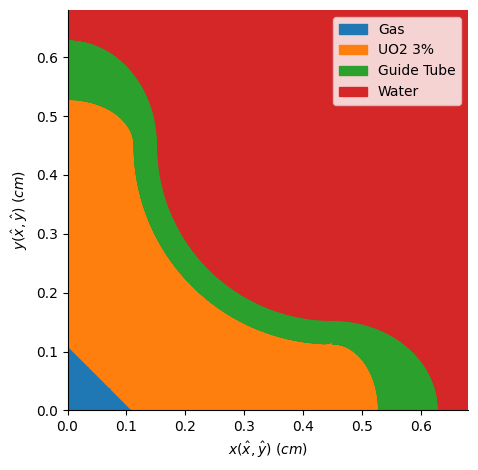

In [6]:
# Plot final mesh
ax = mesh.plot(num_nodes=128, plot_ctrlpts=False)
plt.tight_layout()
plt.savefig("./figs/four_lobe_gas.png", dpi=300)
plt.show()

## Assembler Matrix and TT Operators

In [7]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save COO information
assembler.save_info("./coo_info_gas.csv")

# Create operators in TT format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    max_processes=4,
)
tts = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_info("./tt_info_gas.csv")

Running MatrixAssembler.build()
Discretization: N = 16, G = 7, P = 12, A = 5, B = 5
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/12 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 3.04 s)
Step            Ranks                     Compression
H               33600,33600                   775.62
B_out           33600,33600                  7776.65
B_in            33600,33600                  7593.22
S               2,2100,2100                    17.70
F               2100,2100                      64.64
Running TTAssembler.build()
Discretization: N = 16, G = 7, P = 12, A = 5, B = 5
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/12 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 19.55 s)
Step            Ranks                     Compression
H               3,3,3,6,23,14               38565.28
B_out           4,6,10,10,22,3              29168.32
B_in            8,10,14,14,25,4             17747.59
S               3,3,2,3,9,7                186913.91
F               1,1,1,1,3,6               1021683.26


...

ORx_in          4,45,19,36,18,6,2              14.95       33.27
ORy_in          4,16,2,2,6,6,3                184.01       33.27
ORJx_det_in     4,45,19,36,18,6,2              14.95       33.31
ORJy_det_in     4,16,2,2,6,6,3                184.01       33.31


Intg_bound_in   3,8,27,21,3                137518.16       33.75
H_bound_in      6,25,21,21,21,3           1181048.52       33.86
B_in            6,25,21,21,21,3           115566268.32       33.86
Jx_det_out      2,3                             0.73       33.88
Jy_det_out      1,1                             3.27       33.88
Rx_out          2,9,6,2                         1.03       33.90
Ry_out          2,6,6,3                         1.31       33.90


Ox_out          4,16,2,1,1                     23.56       34.02
Oy_out          4,16,2,1,1                     23.56       34.02
ORx_out         4,45,19,36,18,6,2              14.95       34.06
ORy_out         4,16,2,2,6,6,3                184.01       34.06
ORJx_det_out    4,45,19,36,18,6,2              14.95       34.10
ORJy_det_out    4,16,2,2,6,6,3                184.01       34.10


Intg_bound_out  4,24,21,3                     303.06       34.51
H_bound_out     4,24,21,21,21,3             15856.77       34.53
B_out           4,24,21,21,21,3             15856.77       34.53



Final Operators
H               3,3,3,6,24,34             375651253.69       35.69
S               3,3,2,3,9,22              1368184615.83       35.69
F               1,1,1,1,3,19              5160103735.84       35.69
B_in            8,38,101,101,43,4         13794035.57       35.69
B_out           4,34,97,97,40,3           15893262.72       35.69


## Solve

In [8]:
k, psi = eig(
    LHS=LinearOperator([tts.H, mats.B_out - mats.B_in, -tts.S], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([tts.F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
    linear_solver_opts={
        "max_iterations": 75,
        "threshold": 1e-10,
        "resets": 20,
    },
)

# Save solution
mesh.save(path="mesh_gas.hdf5", solution=psi, k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

Starting power iteration
-- (0): k = 1.2568453, Angular Flux L2-Error = 3.5678095, Elapsed Time = 40.15
-- (1): k = 1.25975606, Angular Flux L2-Error = 0.00129532, Elapsed Time = 80.216
-- (2): k = 1.25975547, Angular Flux L2-Error = 2.88e-06, Elapsed Time = 118.982
-- (3): k = 1.25975547, Angular Flux L2-Error = 1e-08, Elapsed Time = 131.781
-- Converged: k = 1.25975547, Elapsed Time = 131.782


-- (0): k = 0.99640464, Angular Flux L2-Error = 3.31150937, Elapsed Time = 1410.818


-- (1): k = 1.23634573, Angular Flux L2-Error = 0.098026, Elapsed Time = 2822.162


-- (2): k = 1.25575508, Angular Flux L2-Error = 0.00904945, Elapsed Time = 4233.624


-- (3): k = 1.25698621, Angular Flux L2-Error = 0.00353404, Elapsed Time = 5645.012


...

-- (59): k = 1.25710226, Angular Flux L2-Error = 2e-08, Elapsed Time = 84688.141


-- (60): k = 1.25710226, Angular Flux L2-Error = 2e-08, Elapsed Time = 86099.528


-- (61): k = 1.25710226, Angular Flux L2-Error = 1e-08, Elapsed Time = 87510.846


-- (62): k = 1.25710226, Angular Flux L2-Error = 1e-08, Elapsed Time = 88922.247


-- (63): k = 1.25710226, Angular Flux L2-Error = 1e-08, Elapsed Time = 90333.56
-- Converged: k = 1.25710226, Elapsed Time = 90333.561


In [9]:
# Get OpenMC solution
k_mc = [1.25669, 0.00007]
phi_mc = np.load("./openmc/openmc_gas/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print("keff error: {} +/- {} pcm".format((k - k_mc[0]) * 1e5, k_mc[1]))

keff error: 306.5470290587235 +/- 7e-05 pcm


<Figure size 640x480 with 0 Axes>

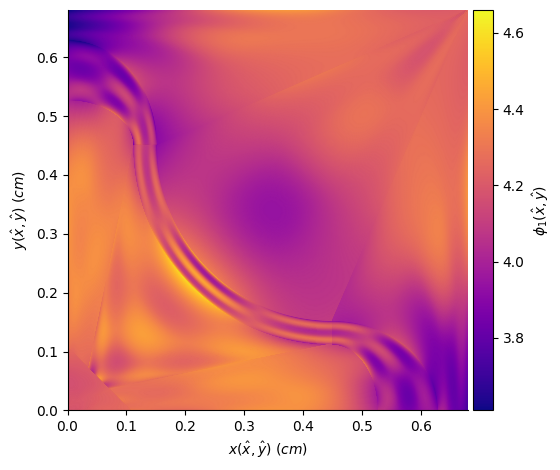

<Figure size 640x480 with 0 Axes>

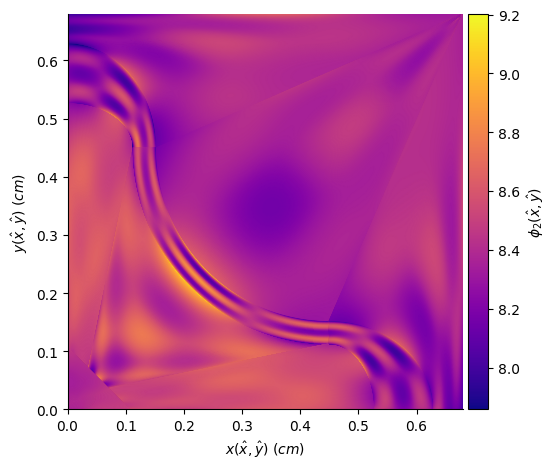

<Figure size 640x480 with 0 Axes>

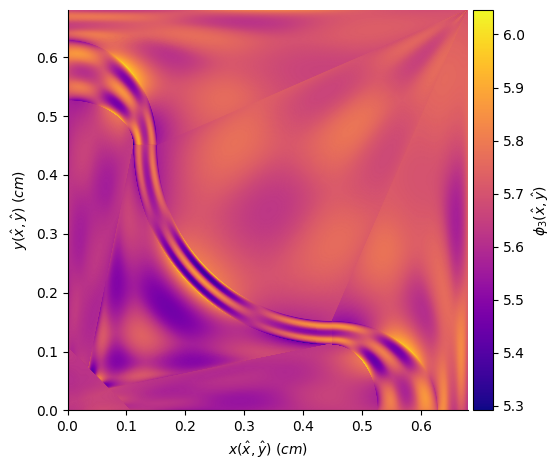

<Figure size 640x480 with 0 Axes>

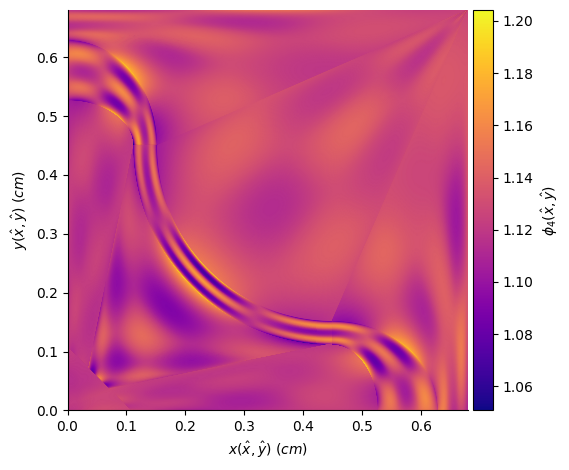

<Figure size 640x480 with 0 Axes>

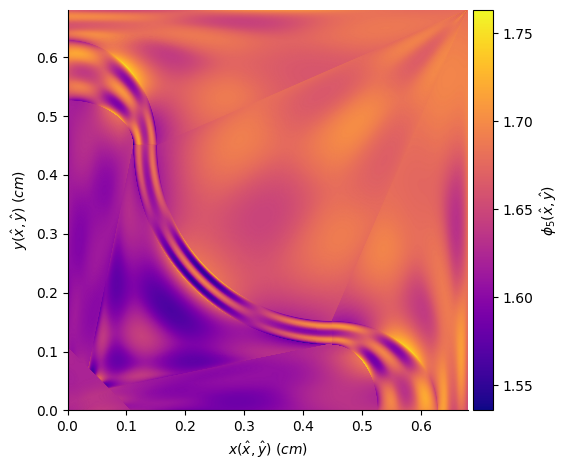

<Figure size 640x480 with 0 Axes>

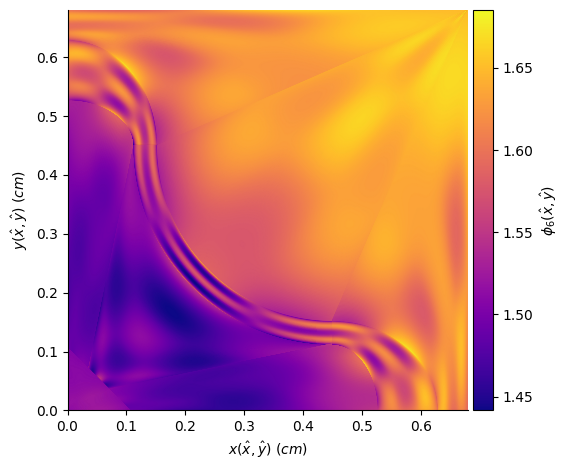

<Figure size 640x480 with 0 Axes>

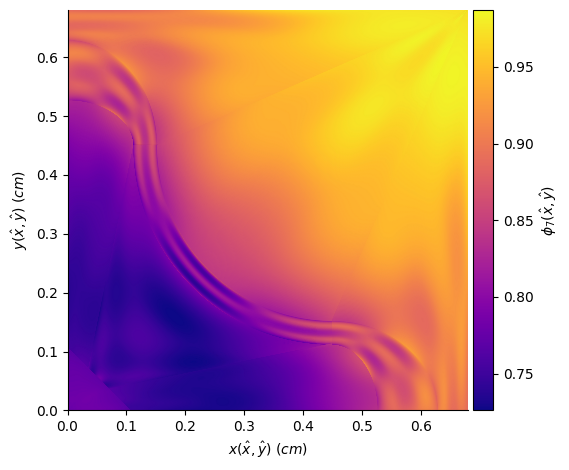

In [10]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(5, 5))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False)
    cbar.set_label(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_gas.png", dpi=300)
    plt.show()

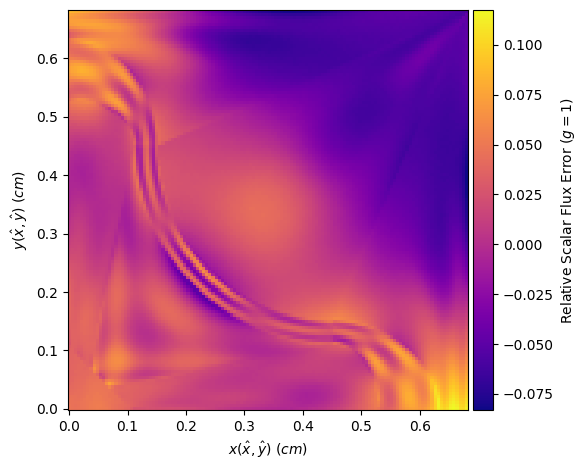

Scalar flux Relative L2-error (g = 1): 0.03702018201716622


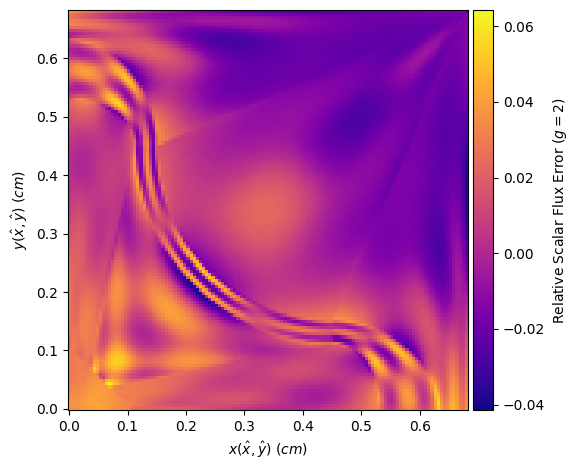

Scalar flux Relative L2-error (g = 2): 0.017831658554514206


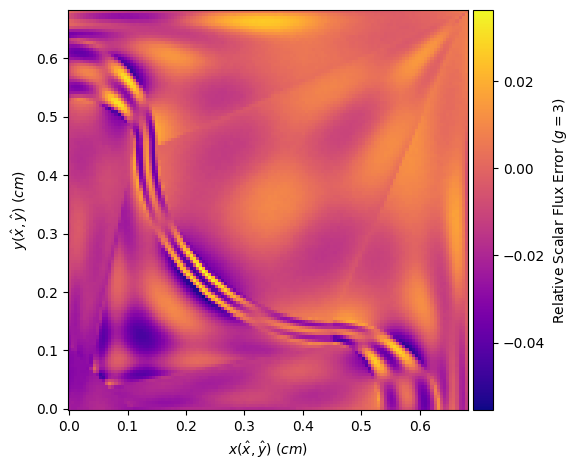

Scalar flux Relative L2-error (g = 3): 0.013613559455356644


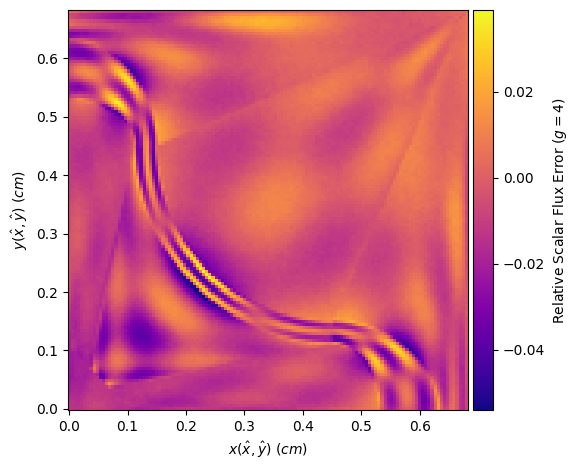

Scalar flux Relative L2-error (g = 4): 0.01163960740274479


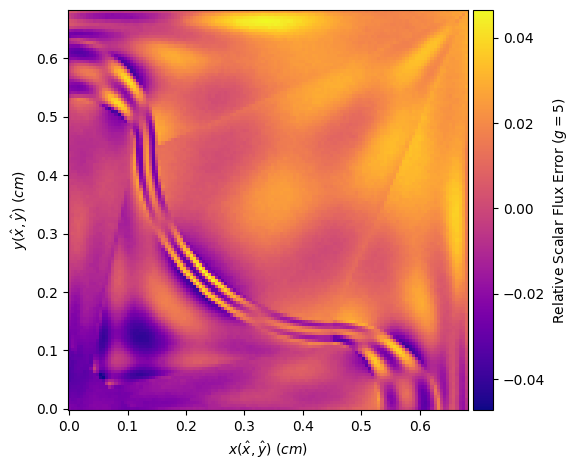

Scalar flux Relative L2-error (g = 5): 0.017815134303912038


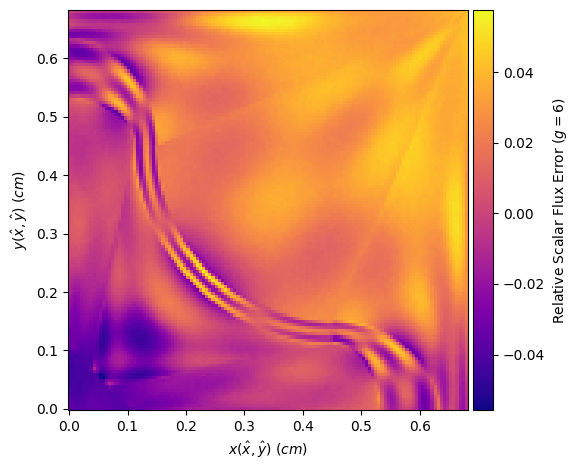

Scalar flux Relative L2-error (g = 6): 0.025895690115445246


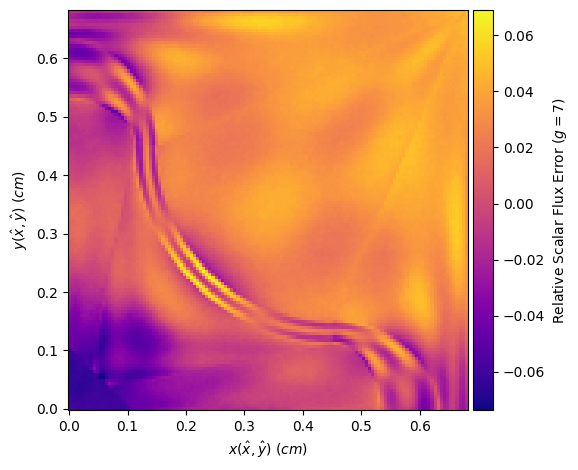

Scalar flux Relative L2-error (g = 7): 0.030596974435552805
Total scalar flux Relative L2-error: 0.020929228809658737


In [11]:
# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

# Regular mesh
X, Y = np.meshgrid(
    np.linspace(0, X / 2, phi_mc.shape[1]),
    np.linspace(0, X / 2, phi_mc.shape[2]),
)

for g in range(xs_server.num_groups):    
    # Plot relative error
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(
        X, Y, (phi_mc[g,] - phi_avg[g,]) / phi_mc[g,], cmap="plasma"
    )
    divider = make_axes_locatable(ax)

    plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
        label=f"Relative Scalar Flux Error ($g = {g + 1}$)",
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi{g + 1}_gas_error.png", dpi=300)
    plt.show()
    
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)